## **Fake-Real news detector using CNN model based supervised learning**
### Fernando P. T. V. A - IT22244802

In here, I am going to use the CNN model to implement the fake-real news detector using the dataset which contains near 25000 data raws.

### Step 01: Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# imports needed
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Clean and Encode Labels
from sklearn.preprocessing import LabelEncoder

# Split Train/Test sets
from sklearn.model_selection import train_test_split

# Tokenize and Pad Texts
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Build CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Train the Model
from tensorflow.keras.callbacks import EarlyStopping

# Confusion Matrix and Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ROC curve and AUC score
from sklearn.metrics import roc_curve, roc_auc_score


In [3]:
# Path for the dataset in Google Drive
data_path = "/content/drive/MyDrive/Colab Notebooks/DL Final Assignment - Fake real news detector/news.csv"

### Step 02: Load the dataset

In [4]:
df = pd.read_csv(data_path)

print("Dataset shape: ", df.shape)
print("\nColumns: ", df.columns)
df.head()

# Keep only rhe "text" and "label" columns
df = df[['text', 'label']]

# Drop missing values
df.dropna(inplace=True)

print("\nAfter cleaning: ", df.shape)
df.head()

/tmp/ipython-input-1692530609.py:1: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263

Dataset shape:  (29160, 532)

Columns:  Index(['text', 'label', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 522', 'Unnamed: 523', 'Unnamed: 524', 'Unnamed: 525',
       'Unnamed: 526', 'Unnamed: 527', 'Unnamed: 528', 'Unnamed: 529',
       'Unnamed: 530', 'Unnamed: 531'],
      dtype='object', length=532)

After cleaning:  (29095, 2)


,text,label
0,radaronline.com/exclusives/2018/07/george-mich...,real
1,LONDON (Reuters) - Britain will be in the â€œf...,real
2,GENEVA/LONDON (Reuters) - The World Health Org...,real
3,(Reuters) - Financial markets have fretted abo...,real
4,"The Republican Party should be so fortunate, a...",fake


### Step 03: Clean and Encode Labels

In [5]:
# Reload dataset to avoid prior transformations
df = pd.read_csv(data_path)

# Keep only text and label columns
df = df[['text', 'label']]

# Drop missing values
df.dropna(inplace=True)

# Convert all labels to lowercase
df['label'] = df['label'].str.lower()

# Keep only 'real' and 'fake' classes (remove other truth levels)
df = df[df['label'].isin(['real', 'fake'])]

print("Unique labels after filtering:", df['label'].unique())
print(df['label'].value_counts())

# Encode labels (Fake=0, Real=1)
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

print("\nEncoded label distribution:")
print(df['label'].value_counts())

/tmp/ipython-input-1863004235.py:2: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263

Unique labels after filtering: ['real' 'fake']
label
fake    15137
real    13948
Name: count, dtype: int64

Encoded label distribution:
label
0    15137
1    13948
Name: count, dtype: int64


### Step 04: Split Train/Test sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 23268
Testing samples: 5817


### Step 05: Tokenize and Pad Texts

In [7]:
max_words = 10000   # max vocab size
max_len = 300       # max words per news article

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print("Padded training data shape:", X_train_pad.shape)

Padded training data shape: (23268, 300)


### Step 06: Build CNN model

In [8]:
embedding_dim = 100

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Step 07: Train the Model

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 63s 209ms/step - accuracy: 0.7537 - loss: 0.4531 - val_accuracy: 0.9235 - val_loss: 0.1419
Epoch 2/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 83s 212ms/step - accuracy: 0.9533 - loss: 0.1134 - val_accuracy: 0.9338 - val_loss: 0.1354
Epoch 3/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 78s 199ms/step - accuracy: 0.9850 - loss: 0.0497 - val_accuracy: 0.9358 - val_loss: 0.1554
Epoch 4/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 81s 197ms/step - accuracy: 0.9977 - loss: 0.0148 - val_accuracy: 0.9366 - val_loss: 0.1719
Epoch 5/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 84s 206ms/step - accuracy: 0.9991 - loss: 0.0081 - val_accuracy: 0.9360 - val_loss: 0.1944


### Step 08: Test on New Example

In [10]:
# Test on New Example
def predict_news(news_text):
    seq = tokenizer.texts_to_sequences([news_text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    pred = model.predict(pad)[0][0]
    label = "Real" if pred > 0.5 else "Fake"
    print(f"Prediction: {label} ({pred:.3f})")

# Test usage
predict_news("The president announced a new plan to reduce inflation.")
predict_news("Aliens landed in New York and took selfies with tourists!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
Prediction: Fake (0.407)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Prediction: Real (0.613)


### **Evaluate the CNN model**

### Step 09: Test Accuracy and Loss

Test Accuracy: 93.36%


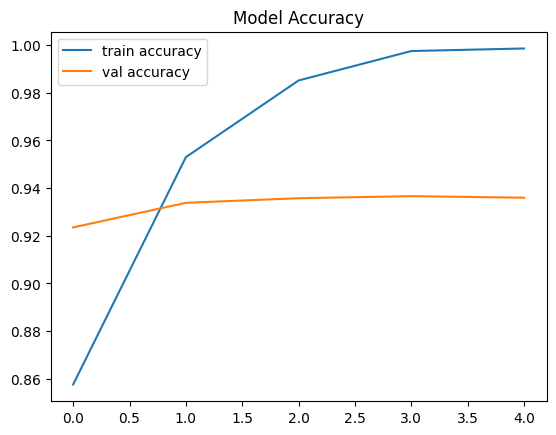

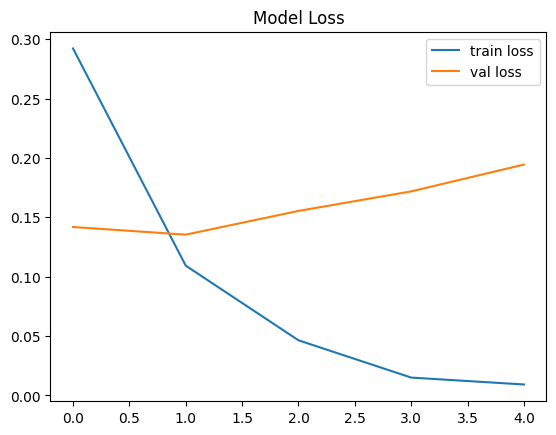

In [11]:
# Evaluate Model
import matplotlib.pyplot as plt

loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")

# Plot training history
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Model Loss')
plt.show()

### Step 10: Confusion Matrix and Metrics

182/182 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step


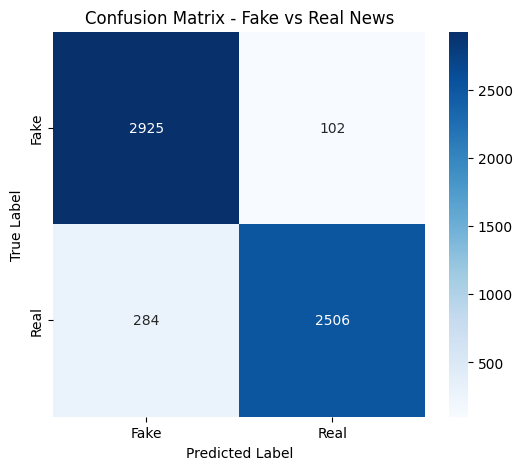


Classification Report:
               precision    recall  f1-score   support

        Fake       0.91      0.97      0.94      3027
        Real       0.96      0.90      0.93      2790

    accuracy                           0.93      5817
   macro avg       0.94      0.93      0.93      5817
weighted avg       0.94      0.93      0.93      5817

Overall Accuracy: 0.9336427711878975


In [12]:
# Predict on the test set
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Fake', 'Real']

# Display confusion matrix as heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Fake vs Real News')
plt.show()

# Print detailed metrics
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=labels))
print("Overall Accuracy:", accuracy_score(y_test, y_pred))

### Step 11: ROC curve and AUC Score

182/182 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step


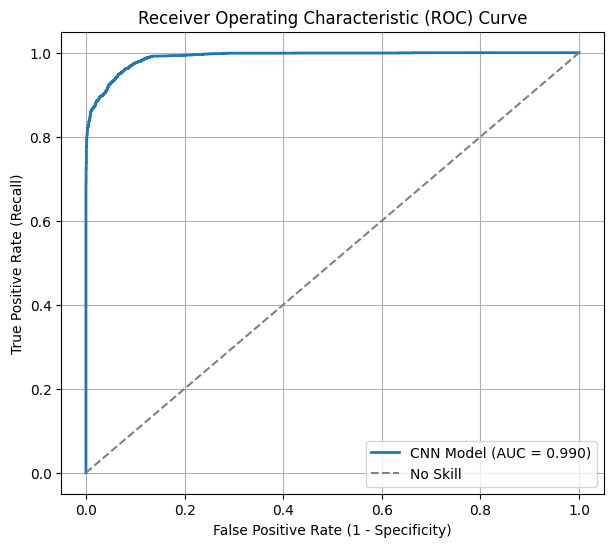


AUC Score: 0.990


In [13]:
# Get predicted probabilities for the positive class ("Real")
y_pred_probs = model.predict(X_test_pad).ravel()

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Plot ROC curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'CNN Model (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='No Skill')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"\nAUC Score: {roc_auc:.3f}")